<a href="https://colab.research.google.com/github/phatnguyen63441-ai/Ki-m-nh-ph-n-m-m/blob/main/2001230654_NguyenTanPhat_B2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
# CELL 1: KHAI BÁO THƯ VIỆN
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

# Cài đặt kích thước chữ mặc định cho biểu đồ
plt.rcParams.update({'font.size': 12})

In [25]:
# CELL 2: ĐỌC DỮ LIỆU TỪ FILE CSV
df = pd.read_csv("heart_disease_dataset.csv")

print("Kích thước dữ liệu gốc:", df.shape)
df.head() # Hiển thị 5 dòng đầu tiên

Kích thước dữ liệu gốc: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,state
0,63.0,M,tap,145.0,233.0,yes,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0.0
1,67.0,M,asp,160.0,286.0,no,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2.0
2,67.0,M,asp,120.0,229.0,no,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1.0
3,37.0,M,nap,130.0,250.0,no,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0.0
4,41.0,F,aap,130.0,204.0,no,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0.0


In [26]:
# CELL 3: XỬ LÝ DỮ LIỆU KHUYẾT THIẾU VÀ GÁN NHÃN
print("--- TRƯỚC KHI LÀM SẠCH ---")
print(df.isnull().sum())
print("-" * 25)

# 1. Loại bỏ các dòng bị thiếu nhãn ở cột 'state'
df = df.dropna(subset=['state'])

# 2. Chuyển đổi cột 'state' thành nhị phân (0: Không bệnh, 1: Có bệnh)
df['state'] = (df['state'] > 0).astype(int)

# 3. Điền giá trị thiếu (NaN) cho các cột còn lại
for col in df.columns:
    if df[col].dtype == 'object':
        # Cột chữ: điền bằng giá trị xuất hiện nhiều nhất (mode)
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        # Cột số: điền bằng giá trị trung bình (mean)
        df[col] = df[col].fillna(df[col].mean())

print("\n--- SAU KHI LÀM SẠCH ---")
print(df.isnull().sum())

--- TRƯỚC KHI LÀM SẠCH ---
age          8
sex          8
cp          11
trestbps     8
chol        10
fbs          8
restecg      8
thalach     12
exang        8
oldpeak      8
slope        8
ca          12
thal         8
state       10
dtype: int64
-------------------------

--- SAU KHI LÀM SẠCH ---
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
state       0
dtype: int64


In [27]:
# CELL 4: CHUẨN HOÁ VÀ MÃ HOÁ
# Tách features (X) và target (y)
X = df.drop(columns=['state'])
y = df['state'].values

# Phân loại cột chữ và cột số
categorical_features = ['sex', 'cp', 'fbs']
numeric_features = [col for col in X.columns if col not in categorical_features]

# Khởi tạo bộ tiền xử lý
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features), # Đưa dữ liệu số về cùng tỷ lệ
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features) # Mã hóa One-Hot cho dữ liệu chữ
    ])

X_processed = preprocessor.fit_transform(X)
print("Kích thước X sau khi xử lý:", X_processed.shape)

Kích thước X sau khi xử lý: (293, 15)


In [28]:
# CELL 5: CHIA TẬP DỮ LIỆU
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42)

print("Số mẫu tập Huấn luyện (Train):", X_train.shape[0])
print("Số mẫu tập Kiểm thử (Test):", X_test.shape[0])

Số mẫu tập Huấn luyện (Train): 234
Số mẫu tập Kiểm thử (Test): 59


In [32]:
# CELL 6: XÂY DỰNG VÀ HUẤN LUYỆN MẠNG NƠ-RON
# 1. Khởi tạo mô hình
model = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.2), # Kỹ thuật tránh overfitting
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid') # Phân loại nhị phân
])

# 2. Biên dịch mô hình
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

print("Bắt đầu huấn luyện...")
# 3. Tiến hành huấn luyện (lưu lại kết quả vào biến 'history')
history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_split=0.2, verbose=1)

Bắt đầu huấn luyện...
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - accuracy: 0.6471 - loss: 0.6433 - val_accuracy: 0.6383 - val_loss: 0.6346
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7540 - loss: 0.5740 - val_accuracy: 0.7234 - val_loss: 0.6050
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7914 - loss: 0.5300 - val_accuracy: 0.7660 - val_loss: 0.5810
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7701 - loss: 0.5069 - val_accuracy: 0.8085 - val_loss: 0.5593
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8396 - loss: 0.4693 - val_accuracy: 0.8085 - val_loss: 0.5429
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8342 - loss: 0.4376 - val_accuracy: 0.8085 - val_loss: 0.5378
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8396 - loss: 0.4194 - val_accuracy: 0.8085 - val_loss: 0.5355
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8289 - loss: 0.4161 - val_accuracy: 0.8085 - val_loss: 0.

In [36]:
# CELL 7: ĐÁNH GIÁ MÔ HÌNH TRÊN TẬP TEST
# Dự đoán xác suất
y_pred_probs = model.predict(X_test)

# Chuyển xác suất thành nhãn (0 hoặc 1) với ngưỡng 0.5
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

print("\n" + "="*40)
print("             KẾT QUẢ DỰ ĐOÁN")
print("="*40)
print(f"Độ chính xác tổng thể (Accuracy): {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("Báo cáo phân loại chi tiết:")
print(classification_report(y_test, y_pred, target_names=['Không bệnh (0)', 'Có bệnh (1)']))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step

             KẾT QUẢ DỰ ĐOÁN
Độ chính xác tổng thể (Accuracy): 86.44%

Báo cáo phân loại chi tiết:
                precision    recall  f1-score   support

Không bệnh (0)       0.86      0.91      0.89        35
   Có bệnh (1)       0.86      0.79      0.83        24

      accuracy                           0.86        59
     macro avg       0.86      0.85      0.86        59
  weighted avg       0.86      0.86      0.86        59



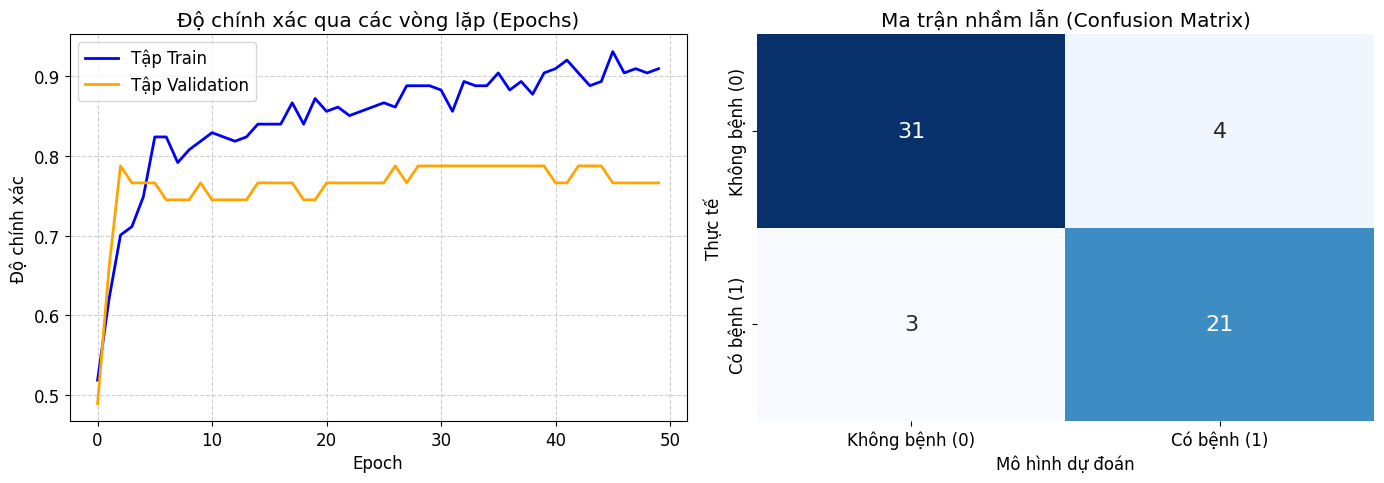

In [31]:
# CELL 8: VẼ BIỂU ĐỒ ĐÁNH GIÁ
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# 1. Biểu đồ thay đổi Độ chính xác (Accuracy)
ax[0].plot(history.history['accuracy'], label='Tập Train', color='blue', linewidth=2)
ax[0].plot(history.history['val_accuracy'], label='Tập Validation', color='orange', linewidth=2)
ax[0].set_title('Độ chính xác qua các vòng lặp (Epochs)')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Độ chính xác')
ax[0].legend()
ax[0].grid(True, linestyle='--', alpha=0.6)

# 2. Biểu đồ Ma trận nhầm lẫn (Confusion Matrix)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax[1],
            annot_kws={"size": 16},
            xticklabels=['Không bệnh (0)', 'Có bệnh (1)'],
            yticklabels=['Không bệnh (0)', 'Có bệnh (1)'])
ax[1].set_title('Ma trận nhầm lẫn (Confusion Matrix)')
ax[1].set_xlabel('Mô hình dự đoán')
ax[1].set_ylabel('Thực tế')

plt.tight_layout()
plt.show()

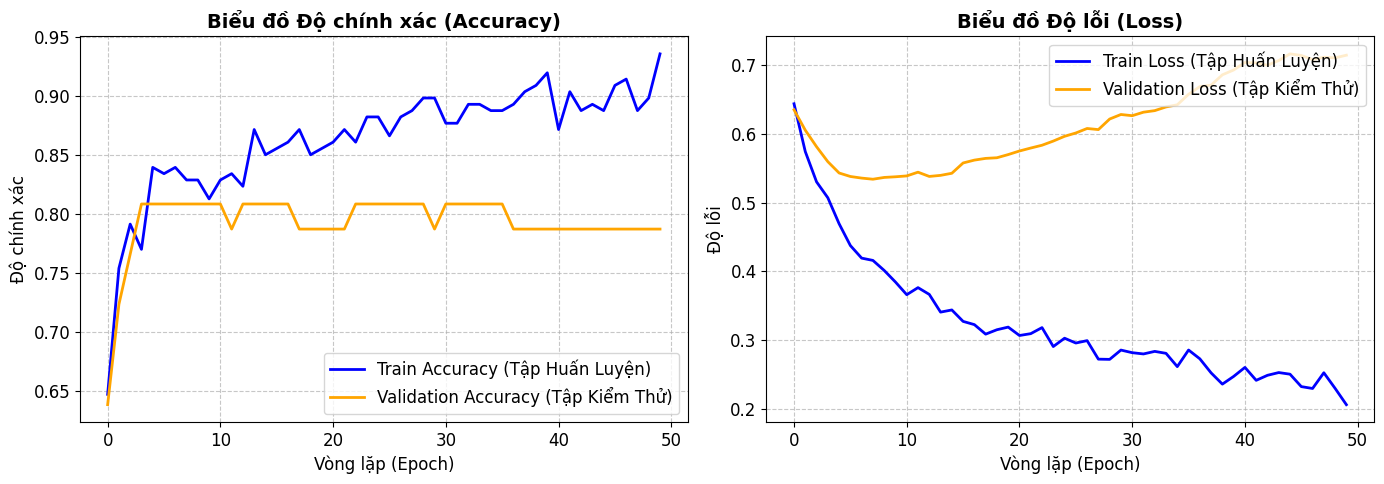

In [38]:
import matplotlib.pyplot as plt

# Tạo một khung hình rộng chứa 2 biểu đồ con (1 hàng, 2 cột)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# ==========================================
# 1. BIỂU ĐỒ ĐỘ CHÍNH XÁC (ACCURACY)
# ==========================================
ax[0].plot(history.history['accuracy'], label='Train Accuracy (Tập Huấn Luyện)', color='blue', linewidth=2)
ax[0].plot(history.history['val_accuracy'], label='Validation Accuracy (Tập Kiểm Thử)', color='orange', linewidth=2)
ax[0].set_title('Biểu đồ Độ chính xác (Accuracy)', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Vòng lặp (Epoch)', fontsize=12)
ax[0].set_ylabel('Độ chính xác', fontsize=12)
ax[0].legend(loc='lower right')
ax[0].grid(True, linestyle='--', alpha=0.7)

# ==========================================
# 2. BIỂU ĐỒ ĐỘ LỖI / MẤT MÁT (LOSS)
# ==========================================
ax[1].plot(history.history['loss'], label='Train Loss (Tập Huấn Luyện)', color='blue', linewidth=2)
ax[1].plot(history.history['val_loss'], label='Validation Loss (Tập Kiểm Thử)', color='orange', linewidth=2)
ax[1].set_title('Biểu đồ Độ lỗi (Loss)', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Vòng lặp (Epoch)', fontsize=12)
ax[1].set_ylabel('Độ lỗi', fontsize=12)
ax[1].legend(loc='upper right')
ax[1].grid(True, linestyle='--', alpha=0.7)

# Hiển thị 2 biểu đồ
plt.tight_layout()
plt.show()

ANN


In [43]:
# CELL: PHƯƠNG PHÁP ANN NÂNG CAO
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

print("Đang khởi tạo cấu trúc mạng ANN Nâng cao...")

# 1. Xây dựng cấu trúc ANN sâu hơn (Thêm lớp và thêm nơ-ron)
advanced_ann = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3), # Tắt 30% nơ-ron để chống học vẹt mạnh hơn
    Dense(32, activation='relu'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

# 2. Tùy chỉnh tốc độ học (Learning Rate) của bộ tối ưu hóa Adam
custom_optimizer = Adam(learning_rate=0.001)

advanced_ann.compile(optimizer=custom_optimizer,
                     loss='binary_crossentropy',
                     metrics=['accuracy'])

# 3. Kỹ thuật Dừng sớm (Early Stopping)
# Nếu sau 15 vòng lặp mà val_loss không giảm (không cải thiện), sẽ tự dừng và giữ lại trọng số tốt nhất.
early_stop = EarlyStopping(monitor='val_loss', mode='min', patience=15, restore_best_weights=True, verbose=1)

print("Bắt đầu huấn luyện ANN Nâng cao (Tối đa 100 epochs)...")
# Cài đặt epochs=100 nhưng có thể sẽ dừng sớm hơn nhờ EarlyStopping
history_adv = advanced_ann.fit(X_train, y_train,
                               epochs=100,
                               batch_size=16,
                               validation_split=0.2,
                               callbacks=[early_stop],
                               verbose=0) # Đặt verbose=0 để ẩn bớt log dài dòng, chỉ hiện kết quả cuối

# 4. Dự đoán và đánh giá
y_pred_adv_probs = advanced_ann.predict(X_test)
y_pred_adv = (y_pred_adv_probs > 0.5).astype(int).flatten()

print("\n" + "="*40)
print("     KẾT QUẢ DỰ ĐOÁN ANN NÂNG CAO")
print("="*40)
print(f"Số vòng lặp thực tế đã chạy: {len(history_adv.history['loss'])} / 100")
print(f"Độ chính xác tổng thể (Accuracy): {accuracy_score(y_test, y_pred_adv) * 100:.2f}%\n")
print("Báo cáo phân loại chi tiết:")
print(classification_report(y_test, y_pred_adv, target_names=['Không bệnh (0)', 'Có bệnh (1)']))

Đang khởi tạo cấu trúc mạng ANN Nâng cao...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Bắt đầu huấn luyện ANN Nâng cao (Tối đa 100 epochs)...
Epoch 21: early stopping
Restoring model weights from the end of the best epoch: 6.
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step

     KẾT QUẢ DỰ ĐOÁN ANN NÂNG CAO
Số vòng lặp thực tế đã chạy: 21 / 100
Độ chính xác tổng thể (Accuracy): 89.83%

Báo cáo phân loại chi tiết:
                precision    recall  f1-score   support

Không bệnh (0)       0.89      0.94      0.92        35
   Có bệnh (1)       0.91      0.83      0.87        24

      accuracy                           0.90        59
     macro avg       0.90      0.89      0.89        59
  weighted avg       0.90      0.90      0.90        59



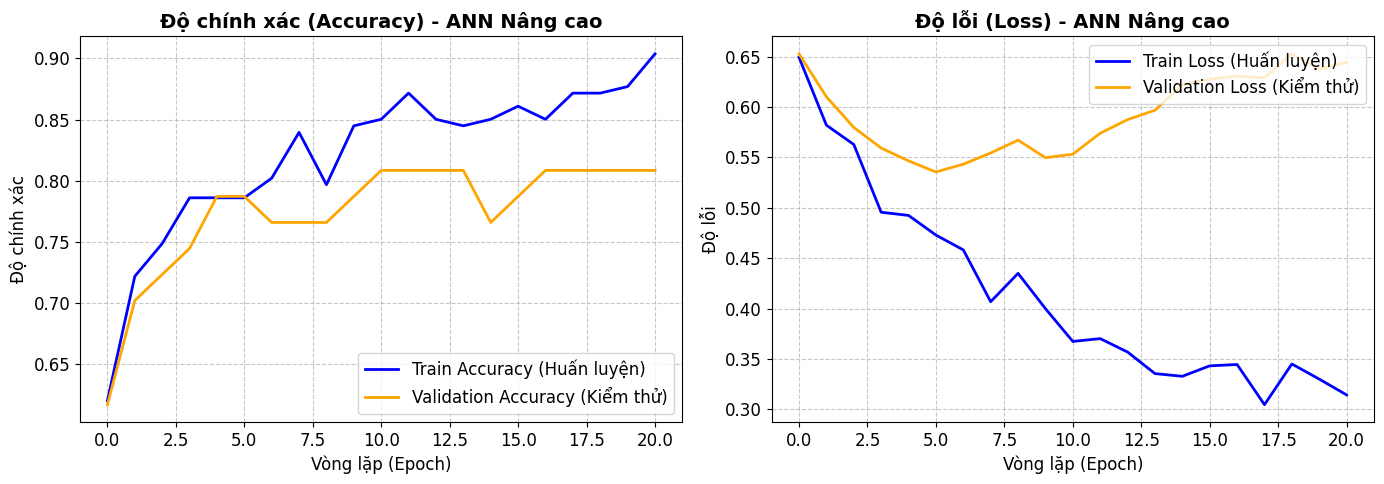

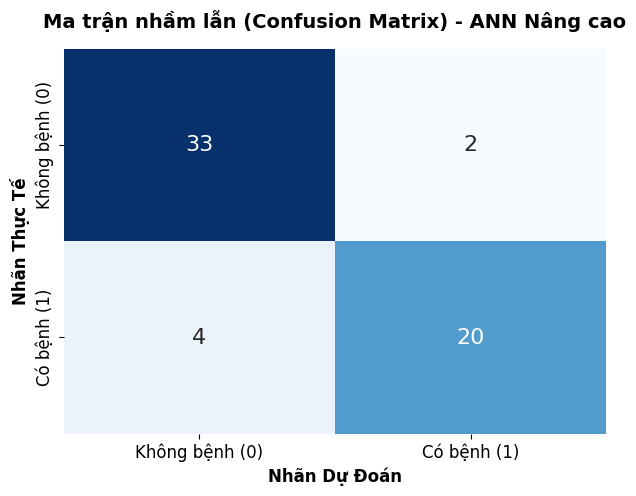

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Tạo một khung hình rộng chứa 2 biểu đồ con (1 hàng, 2 cột)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# ==========================================
# 1. BIỂU ĐỒ ĐỘ CHÍNH XÁC (ACCURACY) & ĐỘ LỖI (LOSS)
# ==========================================
# Cột bên trái: Accuracy
ax[0].plot(history_adv.history['accuracy'], label='Train Accuracy (Huấn luyện)', color='blue', linewidth=2)
ax[0].plot(history_adv.history['val_accuracy'], label='Validation Accuracy (Kiểm thử)', color='orange', linewidth=2)
ax[0].set_title('Độ chính xác (Accuracy) - ANN Nâng cao', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Vòng lặp (Epoch)', fontsize=12)
ax[0].set_ylabel('Độ chính xác', fontsize=12)
ax[0].legend(loc='lower right')
ax[0].grid(True, linestyle='--', alpha=0.7)

# Cột bên phải: Loss
ax[1].plot(history_adv.history['loss'], label='Train Loss (Huấn luyện)', color='blue', linewidth=2)
ax[1].plot(history_adv.history['val_loss'], label='Validation Loss (Kiểm thử)', color='orange', linewidth=2)
ax[1].set_title('Độ lỗi (Loss) - ANN Nâng cao', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Vòng lặp (Epoch)', fontsize=12)
ax[1].set_ylabel('Độ lỗi', fontsize=12)
ax[1].legend(loc='upper right')
ax[1].grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# ==========================================
# 2. MA TRẬN NHẦM LẪN (CONFUSION MATRIX)
# ==========================================
cm = confusion_matrix(y_test, y_pred_adv)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            annot_kws={"size": 16},
            xticklabels=['Không bệnh (0)', 'Có bệnh (1)'],
            yticklabels=['Không bệnh (0)', 'Có bệnh (1)'])

plt.title('Ma trận nhầm lẫn (Confusion Matrix) - ANN Nâng cao', pad=15, fontsize=14, fontweight='bold')
plt.xlabel('Nhãn Dự Đoán', fontweight='bold')
plt.ylabel('Nhãn Thực Tế', fontweight='bold')
plt.show()